In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [98]:
titan=pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\data file ML\titanic.csv")
titan

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Adult
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Youth
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Youth
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Adult


In [99]:
titan.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
AgeGroup         0
dtype: int64

In [100]:
titan.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
AgeGroup        object
dtype: object

In [101]:
a=titan.describe(include="all")
a

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889,891
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3,4
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S,Adult
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644,419
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN,NaN


In [102]:
for i in ["Age"]:
    titan[i]=titan[i].replace(np.nan,a[i][4])


In [103]:
for i in ["Embarked"]:
    titan[i]=titan[i].replace(np.nan,a[i][2])

In [104]:
titan.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
AgeGroup         0
dtype: int64

In [105]:
titan.drop(["PassengerId","Name","Ticket","Cabin"],axis=1,inplace=True)

In [106]:
titan["Age"]=titan["Age"].astype("int64")

In [107]:
for i in titan.columns:
    print(i,":",titan[i].unique(),"\n")

Survived : [0 1] 

Pclass : [3 1 2] 

Sex : ['male' 'female'] 

Age : [22 38 26 35 29 54  2 27 14  4 58 20 39 55 31 34 15 28  8 19 40 66 42 21
 18  3  7 49 65  5 11 45 17 32 16 25  0 30 33 23 24 46 59 71 37 47 70 12
  9 36 51 44  1 61 56 50 62 41 52 63 43 60 10 64 13 48 53 57 80  6 74] 

SibSp : [1 0 3 4 2 5 8] 

Parch : [0 1 2 5 3 4 6] 

Fare : [  7.25    71.2833   7.925   53.1      8.05     8.4583  51.8625  21.075
  11.1333  30.0708  16.7     26.55    31.275    7.8542  16.      29.125
  13.      18.       7.225   26.       8.0292  35.5     31.3875 263.
   7.8792   7.8958  27.7208 146.5208   7.75    10.5     82.1708  52.
   7.2292  11.2417   9.475   21.      41.5792  15.5     21.6792  17.8
  39.6875   7.8     76.7292  61.9792  27.75    46.9     80.      83.475
  27.9     15.2458   8.1583   8.6625  73.5     14.4542  56.4958   7.65
  29.      12.475    9.       9.5      7.7875  47.1     15.85    34.375
  61.175   20.575   34.6542  63.3583  23.      77.2875   8.6542   7.775
  24.15     9

# Visualization

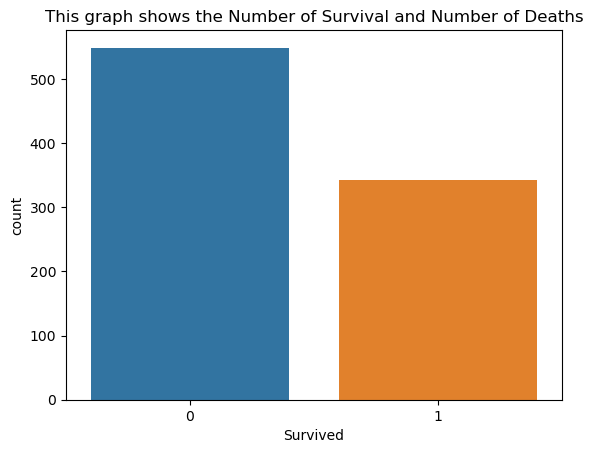

In [108]:
sns.countplot(x="Survived", data=titan)
plt.title("This graph shows the Number of Survival and Number of Deaths")
plt.show()

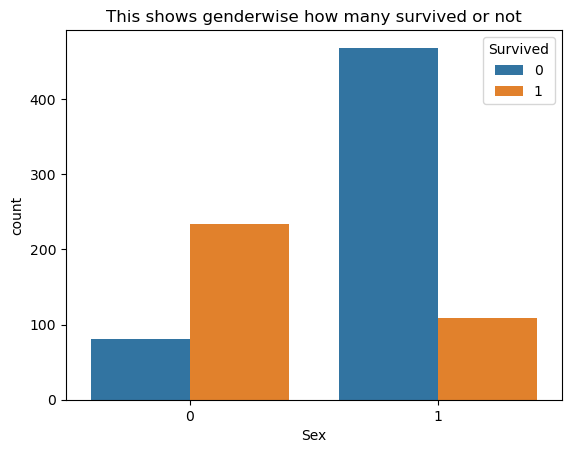

In [126]:
sns.countplot(x="Sex", hue="Survived", data=titan)
plt.title("This shows genderwise how many survived or not")
plt.show()

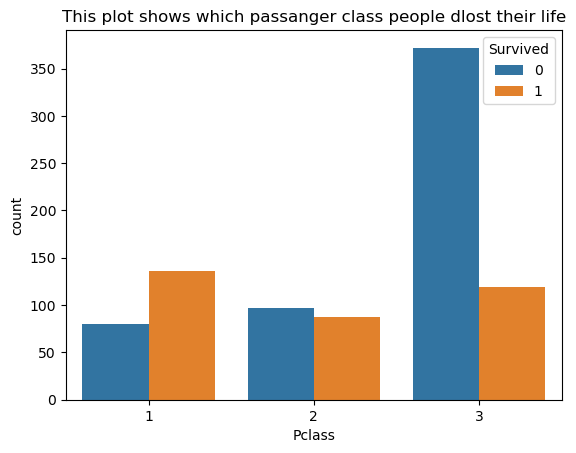

In [110]:
sns.countplot(x="Pclass", hue="Survived", data=titan)
plt.title("This plot shows which passanger class people dlost their life")
plt.show()

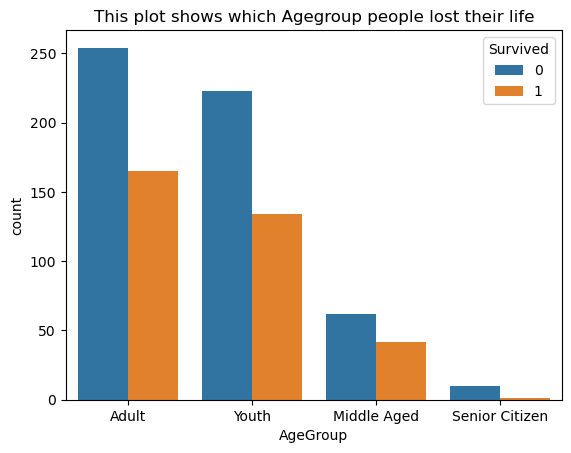

In [111]:
sns.countplot(x="AgeGroup", hue="Survived", data=titan)
plt.title("This plot shows which Agegroup people lost their life")
plt.show()

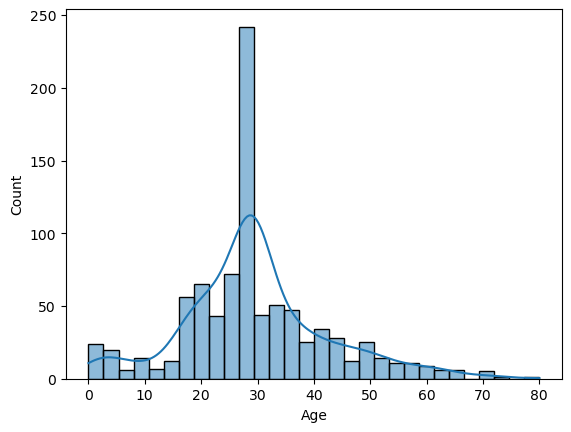

In [112]:
sns.histplot(titan["Age"], kde=True)
plt.show()

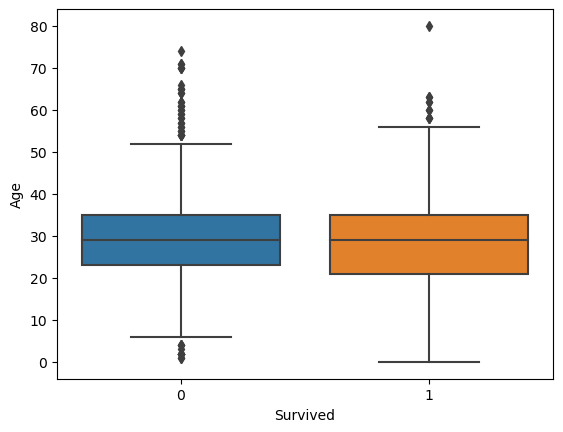

In [113]:
sns.boxplot(x="Survived", y="Age", data=titan)
plt.show()

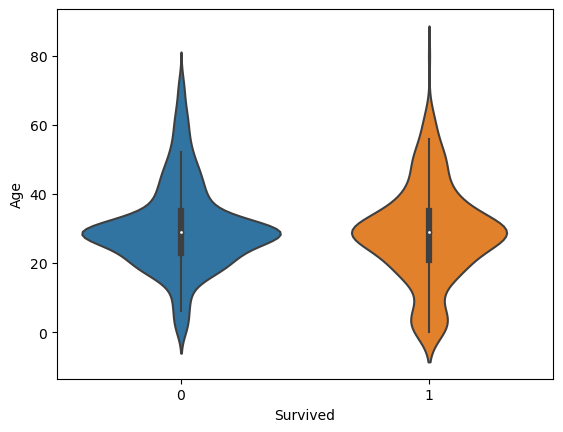

In [114]:
sns.violinplot(x="Survived", y="Age", data=titan)
plt.show()

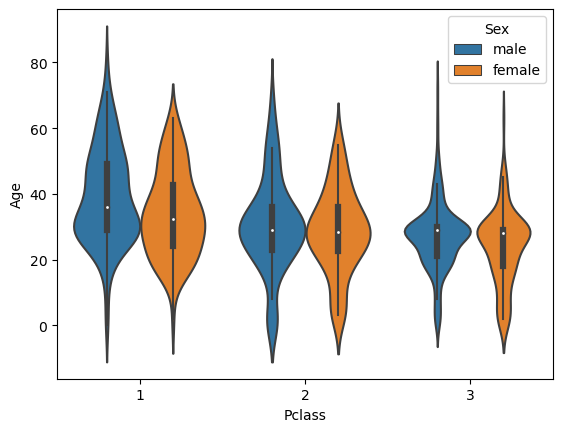

In [115]:
sns.violinplot(x="Pclass", y="Age", hue="Sex", data=titan)
plt.show()

C:\Users\ASUS\anaconda3\Lib\site-packages\seaborn\categorical.py:3544: UserWarning: 19.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\ASUS\anaconda3\Lib\site-packages\seaborn\categorical.py:3544: UserWarning: 5.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\ASUS\anaconda3\Lib\site-packages\seaborn\categorical.py:3544: UserWarning: 25.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\ASUS\anaconda3\Lib\site-packages\seaborn\categorical.py:3544: UserWarning: 12.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


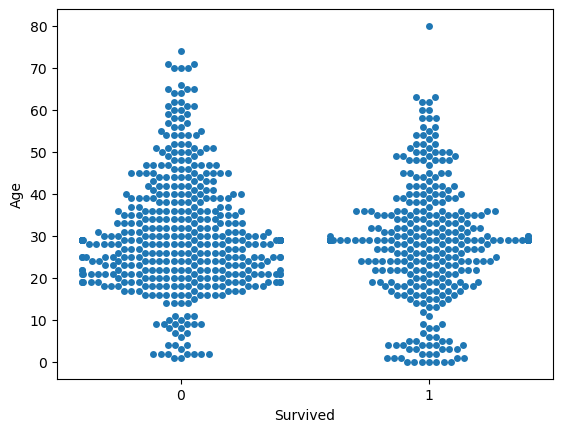

In [116]:
sns.swarmplot(x="Survived", y="Age", data=titan)
plt.show()

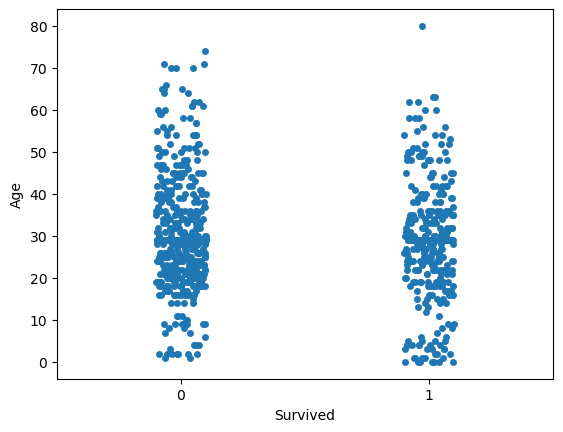

In [117]:
sns.stripplot(x="Survived", y="Age", data=titan)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5740\714677313.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(titan.corr(), annot=True)


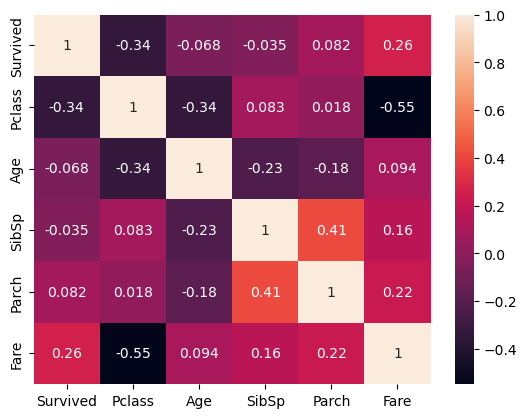

In [118]:
sns.heatmap(titan.corr(), annot=True)
plt.show()

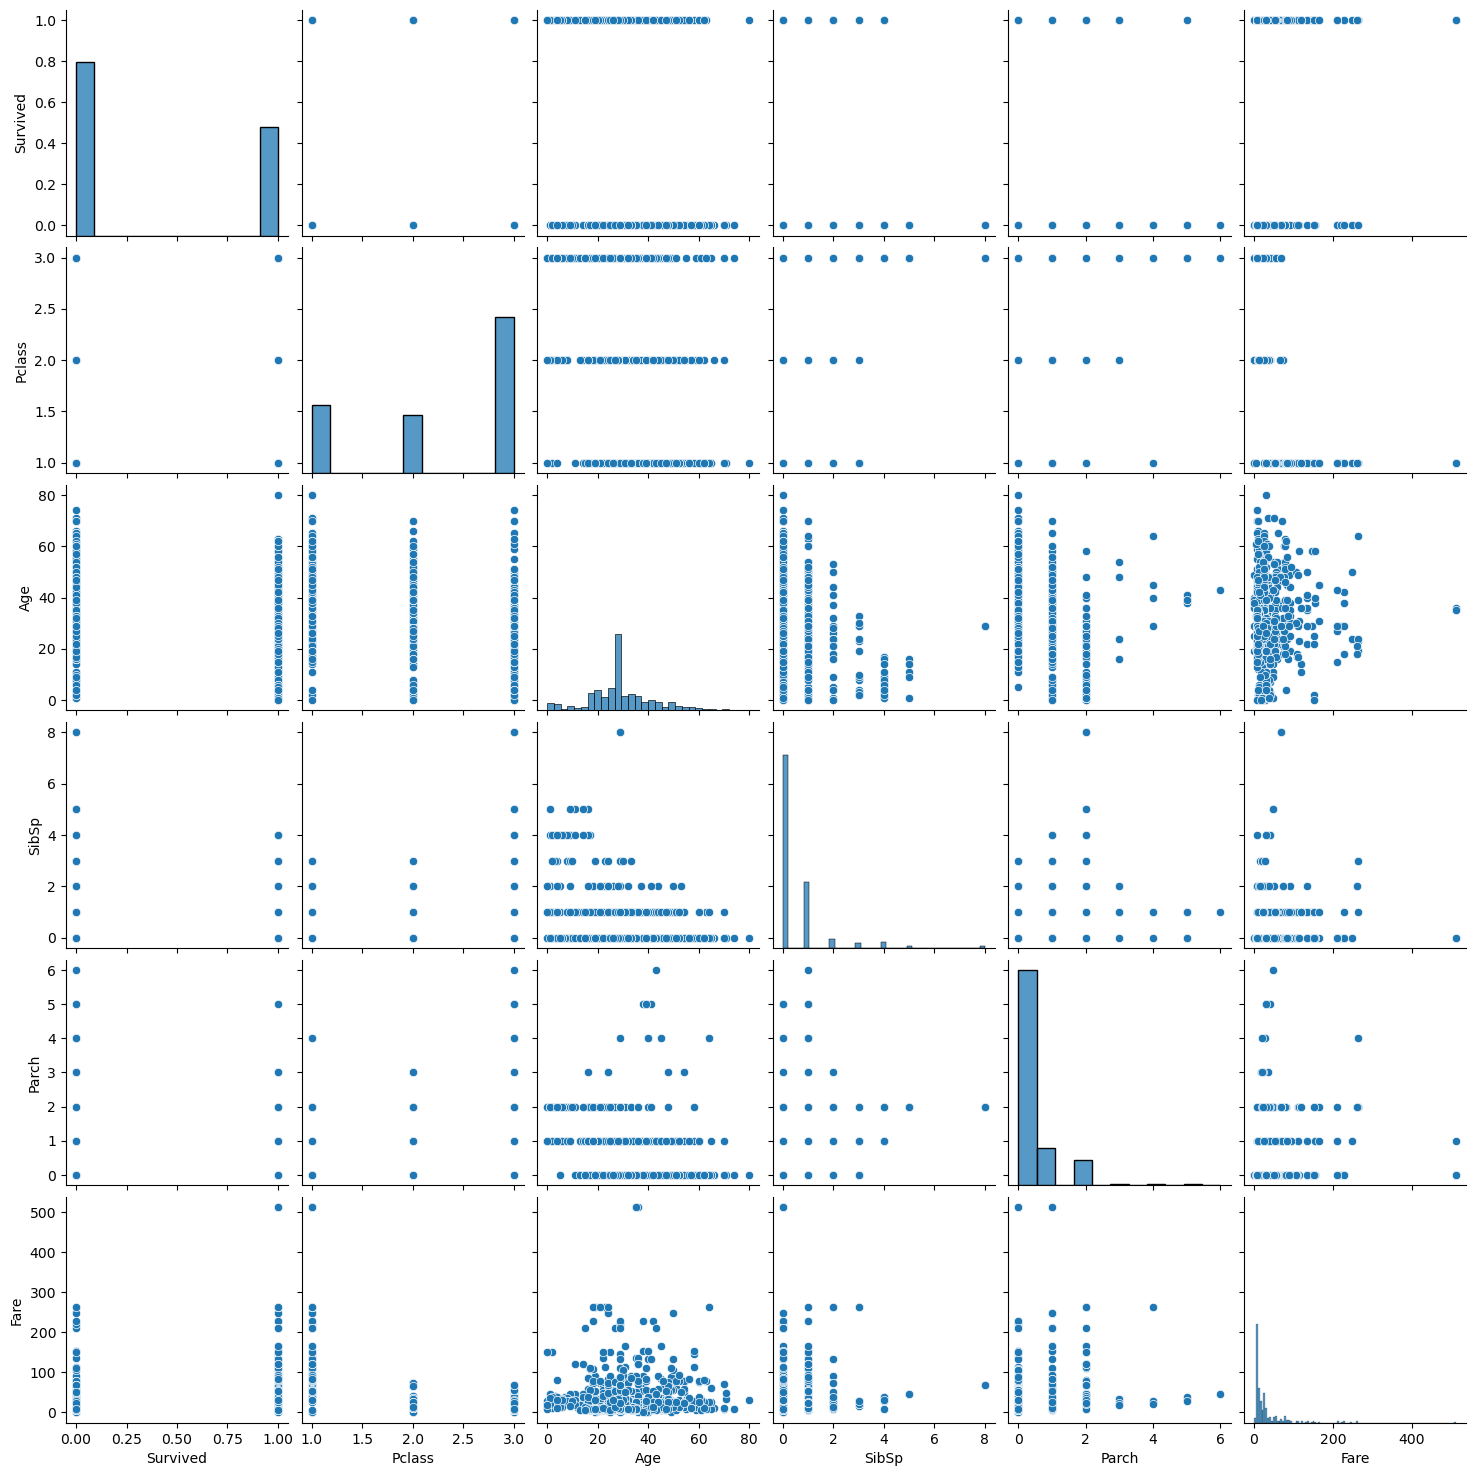

In [119]:
sns.pairplot(titan)
plt.show()

In [120]:
titan.dtypes

Survived      int64
Pclass        int64
Sex          object
Age           int64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
AgeGroup     object
dtype: object

In [121]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [122]:
for i in ["Sex","Embarked","AgeGroup"]:
    titan[i]=le.fit_transform(titan[i])

In [61]:
ip=titan.drop("Survived",axis=1)
op=titan.Survived

In [62]:
ip

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup
0,3,1,22,1,0,7.2500,2,0
1,1,0,38,1,0,71.2833,0,0
2,3,0,26,0,0,7.9250,2,0
3,1,0,35,1,0,53.1000,2,0
4,3,1,35,0,0,8.0500,2,0
...,...,...,...,...,...,...,...,...
886,2,1,27,0,0,13.0000,2,0
887,1,0,19,0,0,30.0000,2,3
888,3,0,29,1,2,23.4500,2,3
889,1,1,26,0,0,30.0000,0,0


In [63]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(ip,op,train_size=0.8)

In [64]:
xtrain

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup
25,3,0,38,1,5,31.3875,2,0
669,1,0,29,1,0,52.0000,2,3
98,2,0,34,0,1,23.0000,2,0
352,3,1,15,1,1,7.2292,0,3
189,3,1,36,0,0,7.8958,2,0
...,...,...,...,...,...,...,...,...
820,1,0,52,1,1,93.5000,2,1
6,1,1,54,0,0,51.8625,2,1
88,1,0,23,3,2,263.0000,2,0
687,3,1,19,0,0,10.1708,2,3


In [65]:
xtest

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup
452,1,1,30,0,0,27.7500,0,0
75,3,1,25,0,0,7.6500,2,0
477,3,1,29,1,0,7.0458,2,0
722,2,1,34,0,0,13.0000,2,0
693,3,1,25,0,0,7.2250,0,0
...,...,...,...,...,...,...,...,...
434,1,1,50,1,0,55.9000,2,1
419,3,0,10,0,2,24.1500,2,3
31,1,0,29,1,0,146.5208,0,3
446,2,0,13,0,1,19.5000,2,3


In [66]:
ytrain

25     1
669    1
98     1
352    0
189    0
      ..
820    1
6      0
88     1
687    0
333    0
Name: Survived, Length: 712, dtype: int64

In [67]:
ytest

452    0
75     0
477    0
722    0
693    0
      ..
434    0
419    0
31     1
446    1
113    0
Name: Survived, Length: 179, dtype: int64

In [68]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()


In [69]:
xtrain=sc.fit_transform(xtrain)

In [70]:
xtrain

array([[ 8.27562699e-01, -1.32653305e+00,  6.36255113e-01, ...,
        -2.16300464e-03,  5.88371400e-01, -9.60087916e-01],
       [-1.57253767e+00, -1.32653305e+00, -4.56520227e-02, ...,
         4.33989289e-01,  5.88371400e-01,  1.17833522e+00],
       [-3.72487488e-01, -1.32653305e+00,  3.33185275e-01, ...,
        -1.79639165e-01,  5.88371400e-01, -9.60087916e-01],
       ...,
       [-1.57253767e+00, -1.32653305e+00, -5.00256780e-01, ...,
         4.89866528e+00,  5.88371400e-01, -9.60087916e-01],
       [ 8.27562699e-01,  7.53844771e-01, -8.03326618e-01, ...,
        -4.51099929e-01,  5.88371400e-01,  1.17833522e+00],
       [ 8.27562699e-01,  7.53844771e-01, -1.03062900e+00, ...,
        -2.85437174e-01,  5.88371400e-01,  1.17833522e+00]])

In [71]:
xtext=sc.transform(xtest)
xtest

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup
452,1,1,30,0,0,27.7500,0,0
75,3,1,25,0,0,7.6500,2,0
477,3,1,29,1,0,7.0458,2,0
722,2,1,34,0,0,13.0000,2,0
693,3,1,25,0,0,7.2250,0,0
...,...,...,...,...,...,...,...,...
434,1,1,50,1,0,55.9000,2,1
419,3,0,10,0,2,24.1500,2,3
31,1,0,29,1,0,146.5208,0,3
446,2,0,13,0,1,19.5000,2,3


# Logistic Regression

In [73]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

In [75]:
lr.fit(xtrain,ytrain)

LogisticRegression()

In [76]:
pred=lr.predict(xtext)
pred

array([1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 1], dtype=int64)

In [79]:
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
cm=confusion_matrix(ytest,pred)
cm

array([[100,  21],
       [ 14,  44]], dtype=int64)

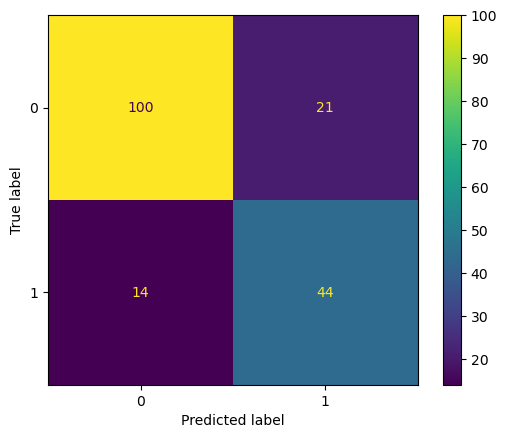

In [80]:
cmd=ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()

In [81]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score
acc=accuracy_score(ytest,pred)
rcc=recall_score(ytest,pred)
prc=precision_score(ytest,pred)
f1=f1_score(ytest,pred)

In [84]:
print(f"Accuracy score:{acc}\nRecall Score:{rcc}\nprecision score:{prc} \nf1_score:{f1}")

Accuracy score:0.8044692737430168
Recall Score:0.7586206896551724
precision score:0.676923076923077 
f1_score:0.7154471544715447


In [124]:
# plotting S-shape curve for classification model
df=pd.DataFrame({"ytest":list(ytest),"prediction":list(pred)})
df.head()

,ytest,prediction
0,0,1
1,0,0
2,0,0
3,0,0
4,0,0


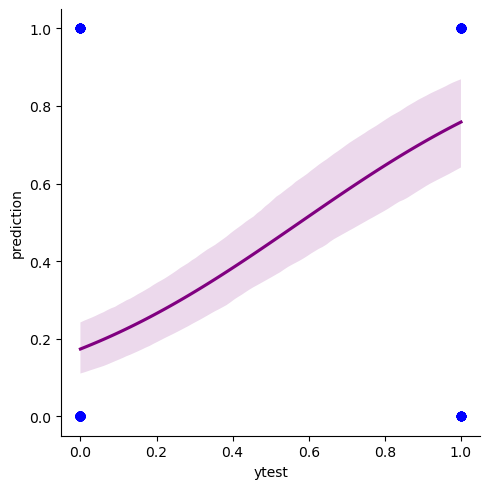

In [125]:
# to plot a logistic regression graph  we will use lmplot()
sns.lmplot(x="ytest",y="prediction",data=df,logistic=True,scatter_kws={"color": "blue"},line_kws={"color": "purple"} )
plt.show()

### KNN

In [85]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)

In [86]:
knn.fit(xtrain,ytrain)

KNeighborsClassifier()

In [87]:
pred1=knn.predict(xtest)
pred1

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\base.py:457: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


array([1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 0], dtype=int64)

In [88]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(ytest,pred1)
cm

array([[68, 53],
       [20, 38]], dtype=int64)

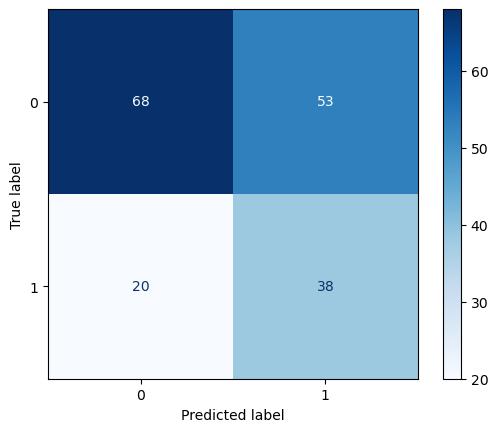

In [89]:
cmd=ConfusionMatrixDisplay(cm)
cmd.plot(cmap='Blues')
plt.show()

In [90]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score
acc=accuracy_score(ytest,pred1)
rec=recall_score(ytest,pred1)
pre=precision_score(ytest,pred1)
f1=f1_score(ytest,pred1)

In [91]:
print(f"Accuracy score:{acc}\nRecall Score:{rec}\nprecision score:{pre} \nf1_score:{f1}")

Accuracy score:0.5921787709497207
Recall Score:0.6551724137931034
precision score:0.4175824175824176 
f1_score:0.5100671140939597
